# Лабораторная работа 15 — Кластеризация

**Цель работы:** изучить методы кластеризации (KMeans, DBSCAN, иерархическая), оценить качество кластеризации метриками и визуализировать результаты на датасете GTZAN.

## Теоретическое введение

**Кластеризация** — задача обучения **без учителя**: разбиение данных на группы (кластеры) так, чтобы объекты внутри одного кластера были похожи, а между кластерами — различны.

### K-Means

Алгоритм K-средних:
1. Выбрать $K$ случайных центроидов
2. Назначить каждый объект ближайшему центроиду
3. Пересчитать центроиды как средние координаты объектов кластера
4. Повторять шаги 2-3 до сходимости

K-Means минимизирует **инерцию** (сумму квадратов расстояний до центроидов). Число кластеров $K$ — гиперпараметр, который выбирают методом «локтя» или по **Silhouette score**.

### DBSCAN

DBSCAN (Density-Based Spatial Clustering) находит кластеры как области высокой плотности, разделённые областями низкой плотности. Не требует задания числа кластеров, но имеет параметры `eps` (радиус окрестности) и `min_samples` (минимальное число точек в окрестности).

### Иерархическая кластеризация

Агломеративный подход: каждый объект — отдельный кластер, затем ближайшие кластеры последовательно объединяются. Результат — **дендрограмма**, позволяющая выбрать число кластеров «визуально».

### Метрики кластеризации

- **Silhouette Score** ∈ [-1, 1]: чем ближе к 1, тем лучше разделение
- **Adjusted Rand Index** (ARI): сравнение с истинными метками, 1 = идеальное совпадение
- **Normalized Mutual Information** (NMI): взаимная информация между кластерами и метками

## 1. Загрузка и предобработка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('../../datasets/gtzan/features_30_sec.csv')
X = df.drop(columns=['filename', 'label', 'length'])
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA для визуализации (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'Датасет: {X.shape[0]} сэмплов, {X.shape[1]} признаков')
print(f'Объяснённая дисперсия PCA (2D): {pca.explained_variance_ratio_.sum():.3f}')

Датасет: 1000 сэмплов, 57 признаков
Объяснённая дисперсия PCA (2D): 0.409


## 2. K-Means: выбор числа кластеров

Используем два подхода: **метод локтя** (inertia) и **Silhouette score**.

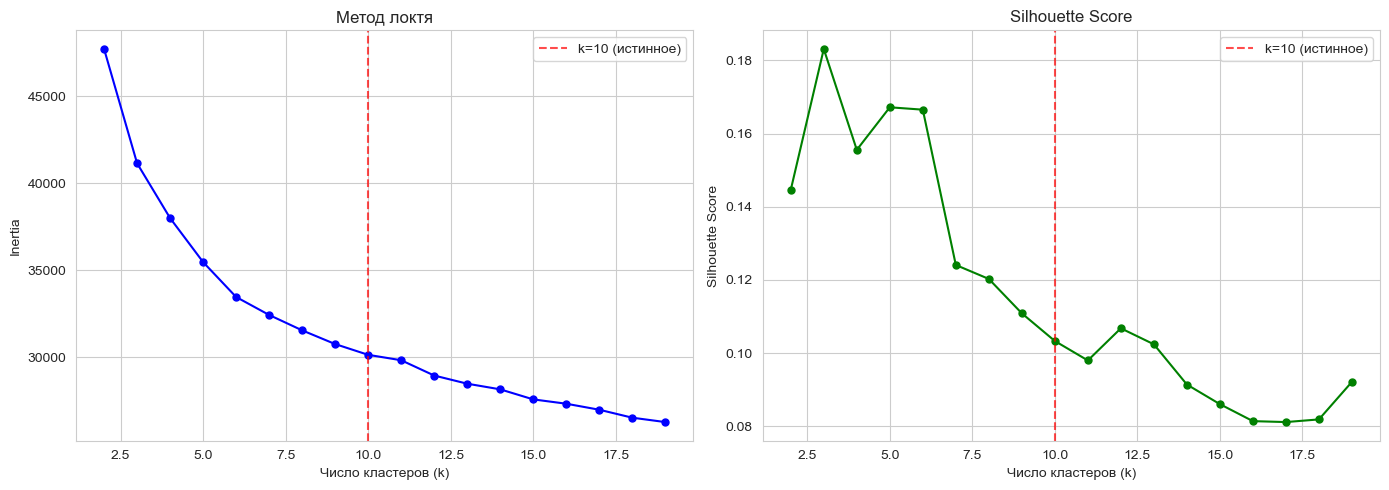

Лучший k по Silhouette: 3


In [8]:
k_range = range(2, 20)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'b-o', markersize=5)
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.7, label='k=10 (истинное)')
axes[0].set_xlabel('Число кластеров (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Метод локтя')
axes[0].legend()

axes[1].plot(k_range, silhouettes, 'g-o', markersize=5)
axes[1].axvline(x=10, color='red', linestyle='--', alpha=0.7, label='k=10 (истинное)')
axes[1].set_xlabel('Число кластеров (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[np.argmax(silhouettes)]
print(f'Лучший k по Silhouette: {best_k_sil}')

## 3. K-Means с k=10 (по числу жанров)

Так как мы знаем, что в GTZAN 10 жанров, применим K-Means с k=10 и сравним кластеры с истинными метками.

=== K-Means (k=10) ===
Silhouette Score: 0.1033
Adjusted Rand Index: 0.1860
Normalized MI: 0.3322
Inertia: 30148.9


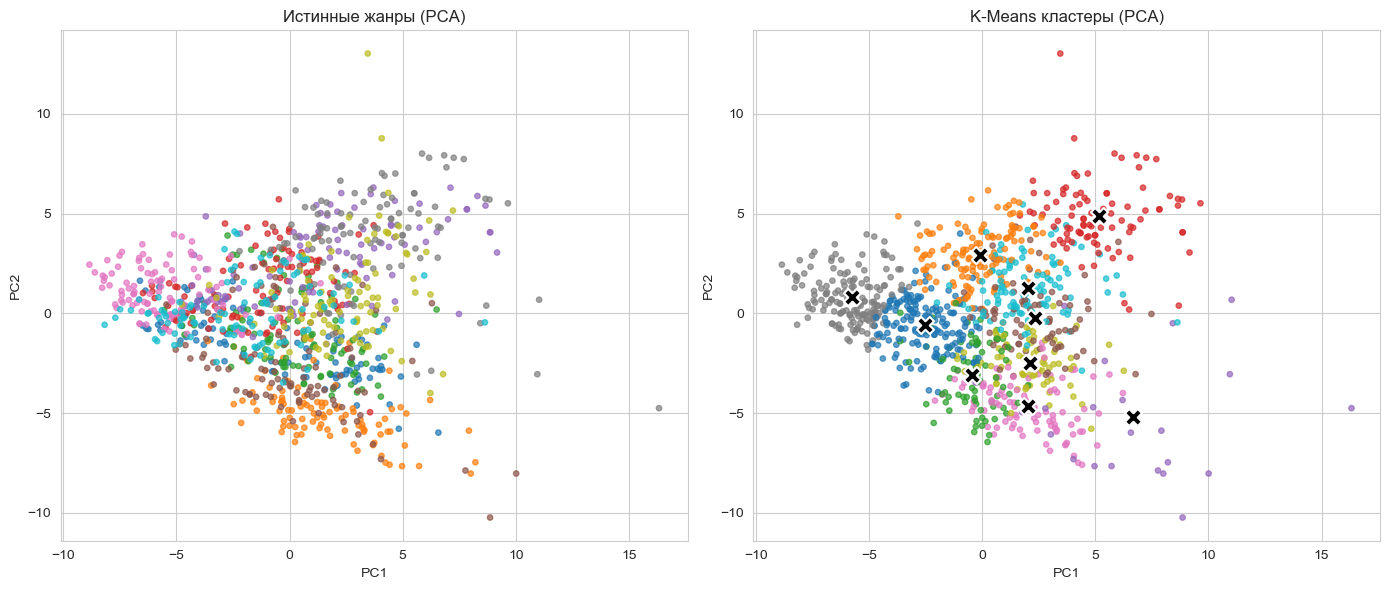

In [3]:
km10 = KMeans(n_clusters=10, random_state=42, n_init=10)
km10.fit(X_scaled)
km_labels = km10.labels_

print('=== K-Means (k=10) ===')
print(f'Silhouette Score: {silhouette_score(X_scaled, km_labels):.4f}')
print(f'Adjusted Rand Index: {adjusted_rand_score(y_encoded, km_labels):.4f}')
print(f'Normalized MI: {normalized_mutual_info_score(y_encoded, km_labels):.4f}')
print(f'Inertia: {km10.inertia_:.1f}')

# Визуализация в PCA-пространстве
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='tab10', s=15, alpha=0.7)
axes[0].set_title('Истинные жанры (PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='tab10', s=15, alpha=0.7)
# Центры кластеров в PCA
centers_pca = pca.transform(km10.cluster_centers_)
axes[1].scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X', s=150, edgecolors='white', linewidths=1.5)
axes[1].set_title('K-Means кластеры (PCA)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

### 3.1 Центры кластеров

Выведем координаты центроидов и определим, какие признаки наиболее различаются между кластерами.

In [4]:
centers_df = pd.DataFrame(km10.cluster_centers_, columns=X.columns)
print('Центры кластеров (первые 8 признаков):')
print(centers_df.iloc[:, :8].round(2).to_string())

# Признаки с наибольшим разбросом между центрами
center_std = centers_df.std()
top_features = center_std.sort_values(ascending=False).head(10)
print(f'\nПризнаки с наибольшим разбросом между центрами:')
for feat, val in top_features.items():
    print(f'  {feat}: std = {val:.3f}')

Центры кластеров (первые 8 признаков):
   chroma_stft_mean  chroma_stft_var  rms_mean  rms_var  spectral_centroid_mean  spectral_centroid_var  spectral_bandwidth_mean  spectral_bandwidth_var
0              0.12            -0.02     -0.02    -0.18                   -0.13                  -0.38                    -0.19                   -0.41
1              0.40            -0.29      0.54    -0.03                    1.15                   0.18                     1.21                   -0.17
2             -0.94            -0.03     -0.78    -0.45                   -1.20                  -0.77                    -1.18                   -0.29
3              0.59             0.69      1.20     2.05                    1.31                   2.06                     1.42                    0.87
4             -1.55             0.59     -0.43    -0.06                   -0.44                  -0.32                    -0.63                   -0.14
5              0.31             0.73     -0.15   

## 4. DBSCAN

DBSCAN автоматически определяет число кластеров и выделяет выбросы (шум). Подберём параметры `eps` и `min_samples`.

DBSCAN: 2 кластеров, 319 шумовых точек
Silhouette (без шума): 0.1150
ARI: 0.0169


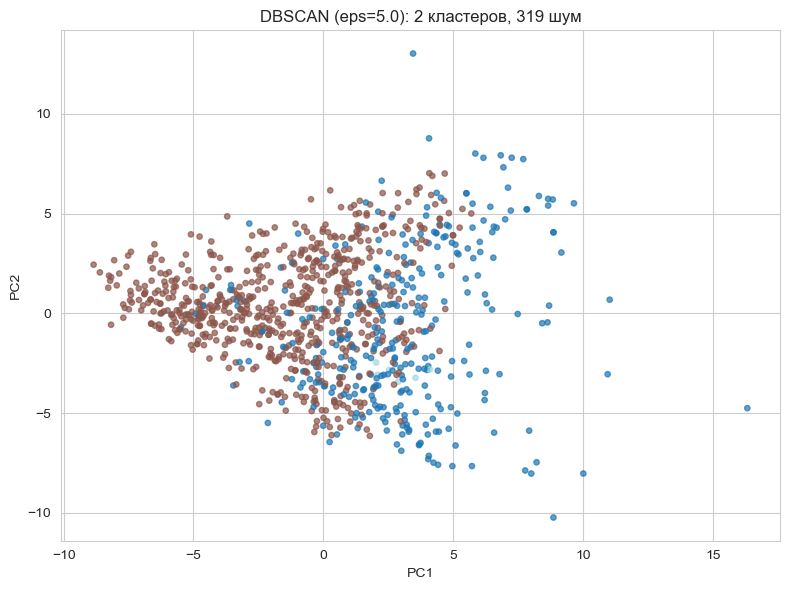

In [18]:
db = DBSCAN(eps=5.0, min_samples=5)
db_labels = db.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f'DBSCAN: {n_clusters_db} кластеров, {n_noise} шумовых точек')
if n_clusters_db > 1:
    mask = db_labels != -1
    print(f'Silhouette (без шума): {silhouette_score(X_scaled[mask], db_labels[mask]):.4f}')
    print(f'ARI: {adjusted_rand_score(y_encoded, db_labels):.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='tab20', s=15, alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'DBSCAN (eps=5.0): {n_clusters_db} кластеров, {n_noise} шум')
plt.tight_layout()
plt.show()

## 5. Иерархическая кластеризация + дендрограмма

Агломеративная кластеризация строит дерево объединений. Дендрограмма помогает визуально определить оптимальное число кластеров.

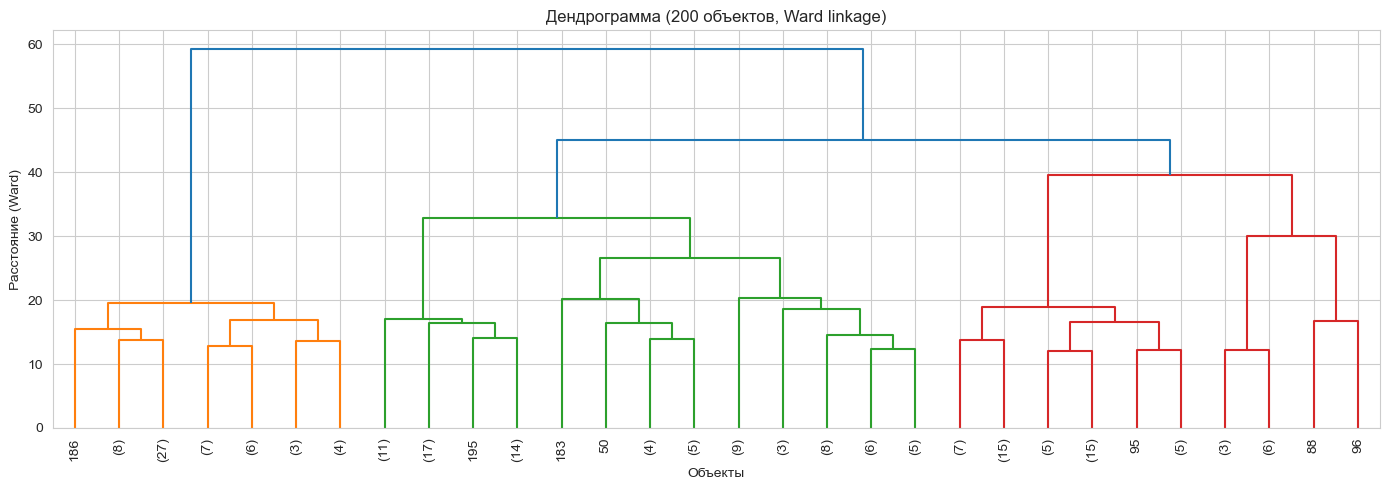

Agglomerative (k=10, Ward):
  Silhouette: 0.0906
  ARI: 0.1863
  NMI: 0.3317


In [6]:
# Дендрограмма (на подвыборке для читаемости)
np.random.seed(42)
idx = np.random.choice(len(X_scaled), 200, replace=False)
Z = linkage(X_scaled[idx], method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=90)
ax.set_xlabel('Объекты')
ax.set_ylabel('Расстояние (Ward)')
ax.set_title('Дендрограмма (200 объектов, Ward linkage)')
plt.tight_layout()
plt.show()

# Agglomerative с k=10
agg = AgglomerativeClustering(n_clusters=10, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

print(f'Agglomerative (k=10, Ward):')
print(f'  Silhouette: {silhouette_score(X_scaled, agg_labels):.4f}')
print(f'  ARI: {adjusted_rand_score(y_encoded, agg_labels):.4f}')
print(f'  NMI: {normalized_mutual_info_score(y_encoded, agg_labels):.4f}')

## 6. Сравнение методов кластеризации

Сравнение методов кластеризации (k=10):
               Silhouette     ARI     NMI
KMeans             0.1033  0.1860  0.3322
Agglomerative      0.0906  0.1863  0.3317


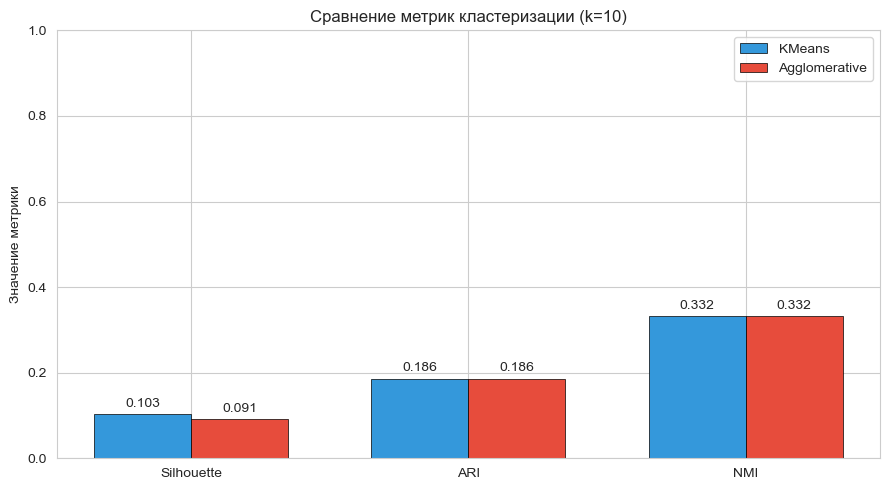

In [19]:
comparison = {
    'KMeans': {
        'Silhouette': silhouette_score(X_scaled, km_labels),
        'ARI': adjusted_rand_score(y_encoded, km_labels),
        'NMI': normalized_mutual_info_score(y_encoded, km_labels),
    },
    'Agglomerative': {
        'Silhouette': silhouette_score(X_scaled, agg_labels),
        'ARI': adjusted_rand_score(y_encoded, agg_labels),
        'NMI': normalized_mutual_info_score(y_encoded, agg_labels),
    },
}

comp_df = pd.DataFrame(comparison).T
print('Сравнение методов кластеризации (k=10):')
print(comp_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(comp_df.columns))
width = 0.35

bars1 = ax.bar(x_pos - width/2, comp_df.iloc[0], width, label='KMeans', color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x_pos + width/2, comp_df.iloc[1], width, label='Agglomerative', color='#e74c3c', edgecolor='black', linewidth=0.5)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x_pos)
ax.set_xticklabels(comp_df.columns)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик кластеризации (k=10)')
ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

## Выводы

1. **K-Means** — простой и быстрый алгоритм, но предполагает сферическую форму кластеров и требует задания $k$. Метод локтя и Silhouette помогают выбрать оптимальное число кластеров.

2. **Центры кластеров** (центроиды) показали, что наибольшие различия между кластерами наблюдаются по MFCC-коэффициентам и спектральным характеристикам — это согласуется с feature importance из предыдущих лабораторных.

3. **DBSCAN** автоматически определяет число кластеров, но чувствителен к выбору `eps`. На высокоразмерных данных GTZAN работает менее эффективно, чем K-Means.

4. **Иерархическая кластеризация** (Ward) даёт сопоставимые с K-Means результаты и позволяет визуализировать иерархию через дендрограмму.

5. Значения ARI и NMI < 1 говорят о том, что кластеры не полностью совпадают с жанрами — это ожидаемо, так как некоторые жанры акустически похожи (rock/country, disco/pop).

6. Кластеризация — полезный инструмент для исследовательского анализа данных, когда метки классов недоступны.